# Finite Wing Aerodynamics — Vortex Lattice Method
## Level: Intermediate

This notebook studies the aerodynamic behavior of finite wings using the
Vortex Lattice Method (VLM). We examine how aspect ratio, taper ratio, and
sweep angle affect lift, induced drag, and spanwise load distribution.

### Topics covered
- Finite wing geometry parameters (AR, taper, sweep, dihedral)
- Induced drag and Oswald efficiency factor
- Spanwise lift distribution
- Effect of wing parameters on aerodynamic performance
- Comparison with Prandtl's lifting-line theory

### References
- Prandtl, L., "Applications of Modern Hydrodynamics to Aeronautics", NACA TR-116, 1921
- Katz, J. and Plotkin, A., *Low Speed Aerodynamics*, Cambridge, 2001
- Bertin, J.J. and Cummings, R.M., *Aerodynamics for Engineers*, Pearson, 2014

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

print("Setting up environment...")
print(f"Current working directory: {os.getcwd()}")

# Resolve project root from this notebook location and add src/ to import path
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))
src_root = os.path.join(project_root, "src")

print(f"Resolved project root: {project_root}")
if not os.path.isdir(src_root):
    raise FileNotFoundError(f"Could not find src directory at: {src_root}")

if src_root not in sys.path:
    sys.path.insert(0, src_root)

print(f"Using src path: {src_root}")
from aerodemo.vlm import WingGeometry, VortexLatticeMethod

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
print("Setup complete.")

Setting up environment...
Current working directory: f:\agodemar\AeroDemonstrator\notebooks\02_finite_wing
Resolved project root: f:\agodemar\AeroDemonstrator
Using src path: f:\agodemar\AeroDemonstrator\src
Setup complete.


## 1. Wing Geometry Parameters

A trapezoidal wing is defined by:
- **Span** $b$: distance from tip to tip [m]
- **Root chord** $c_r$: chord length at wing root [m]
- **Tip chord** $c_t$: chord length at wing tip [m]
- **Taper ratio** $\lambda = c_t / c_r$
- **Aspect ratio** $AR = b^2 / S$, where $S$ is reference area
- **Sweep angle** $\Lambda_{c/4}$: quarter-chord line sweep [degrees]
- **Dihedral** $\Gamma$: angle of wing from horizontal [degrees]

The mean aerodynamic chord (MAC) for a trapezoidal wing:

$$\bar{c} = \frac{2}{3} c_r \frac{1 + \lambda + \lambda^2}{1 + \lambda}$$

In [2]:
# Define a baseline wing
baseline_wing = WingGeometry(
    span=12.0,
    root_chord=2.5,
    tip_chord=1.25,
    sweep_angle=15.0,
    dihedral=3.0,
    n_spanwise=12,
    n_chordwise=4,
)

print("Baseline Wing Properties:")
print(f"  Span:                  b = {baseline_wing.span:.2f} m")
print(f"  Root chord:           cr = {baseline_wing.root_chord:.2f} m")
print(f"  Tip chord:            ct = {baseline_wing.tip_chord:.2f} m")
print(f"  Taper ratio:       λ = {baseline_wing.taper_ratio:.3f}")
print(f"  Reference area:    S = {baseline_wing.reference_area:.3f} m²")
print(f"  Aspect ratio:     AR = {baseline_wing.aspect_ratio:.3f}")
print(f"  MAC:               c̄ = {baseline_wing.mean_aerodynamic_chord:.3f} m")
print(f"  Sweep angle:    Λ₁/₄ = {baseline_wing.sweep_angle:.1f}°")
print(f"  Dihedral:           Γ = {baseline_wing.dihedral:.1f}°")

Baseline Wing Properties:
  Span:                  b = 12.00 m
  Root chord:           cr = 2.50 m
  Tip chord:            ct = 1.25 m
  Taper ratio:       λ = 0.500
  Reference area:    S = 22.500 m²
  Aspect ratio:     AR = 6.400
  MAC:               c̄ = 1.944 m
  Sweep angle:    Λ₁/₄ = 15.0°
  Dihedral:           Γ = 3.0°


## 2. Lift Polar: CL vs. Alpha

We solve the VLM at multiple angles of attack to build the lift curve.

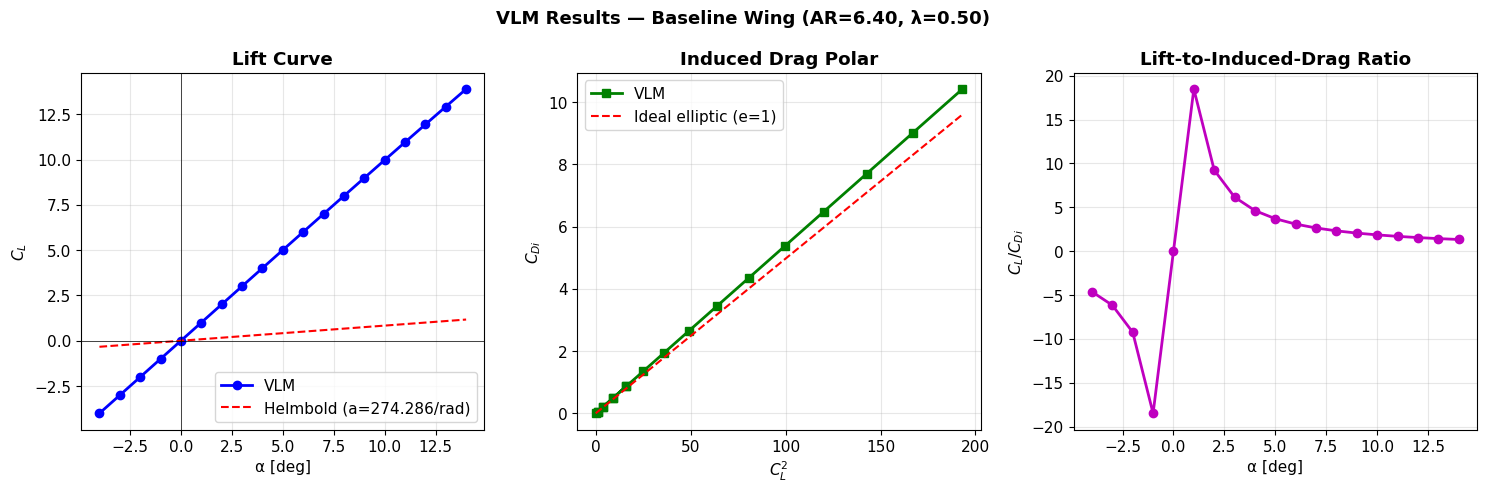

In [3]:
vlm = VortexLatticeMethod(baseline_wing)
alpha_range = np.linspace(-4, 14, 19)
sweep_result = vlm.sweep_alpha(alpha_range)

# Theoretical lift-curve slope for finite wing (Helmbold equation)
AR = baseline_wing.aspect_ratio
a0 = 2 * np.pi  # thin-airfoil 2D slope
a_fin = a0 / (1 + a0 / (np.pi * AR))  # Helmbold approximation

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CL vs alpha
ax = axes[0]
ax.plot(sweep_result['alpha'], sweep_result['CL'], 'bo-', linewidth=2, markersize=6, label='VLM')
alpha_th = np.array([-4, 14])
CL_th = a_fin * np.deg2rad(alpha_th)
ax.plot(alpha_th, CL_th, 'r--', linewidth=1.5, label=f'Helmbold (a={np.rad2deg(a_fin):.3f}/rad)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('α [deg]')
ax.set_ylabel('$C_L$')
ax.set_title('Lift Curve', fontweight='bold')
ax.legend()

# CDi vs CL² (induced drag polar)
ax = axes[1]
CL_arr = sweep_result['CL']
CDi_arr = sweep_result['CDi']
ax.plot(CL_arr**2, CDi_arr, 'gs-', linewidth=2, markersize=6, label='VLM')
CL2_th = np.linspace(0, max(CL_arr)**2, 50)
e_ideal = 1.0
CDi_th = CL2_th / (np.pi * AR * e_ideal)
ax.plot(CL2_th, CDi_th, 'r--', linewidth=1.5, label='Ideal elliptic (e=1)')
ax.set_xlabel('$C_L^2$')
ax.set_ylabel('$C_{Di}$')
ax.set_title('Induced Drag Polar', fontweight='bold')
ax.legend()

# L/D ratio
ax = axes[2]
LoverD = sweep_result['CL_over_CDi']
ax.plot(sweep_result['alpha'], LoverD, 'mo-', linewidth=2, markersize=6)
ax.set_xlabel('α [deg]')
ax.set_ylabel('$C_L / C_{Di}$')
ax.set_title('Lift-to-Induced-Drag Ratio', fontweight='bold')

plt.suptitle(f'VLM Results — Baseline Wing (AR={AR:.2f}, λ={baseline_wing.taper_ratio:.2f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vlm_polar.png', bbox_inches='tight', dpi=100)
plt.show()

## 3. Spanwise Lift Distribution

The spanwise distribution of lift is a key indicator of structural load and
aerodynamic efficiency. An elliptic distribution (ideal) minimizes induced drag.

The local lift per unit span $l(y)$ normalized by $\frac{1}{2}\rho V^2 S$:

$$c_l \cdot c(y) = \text{spanwise loading}$$

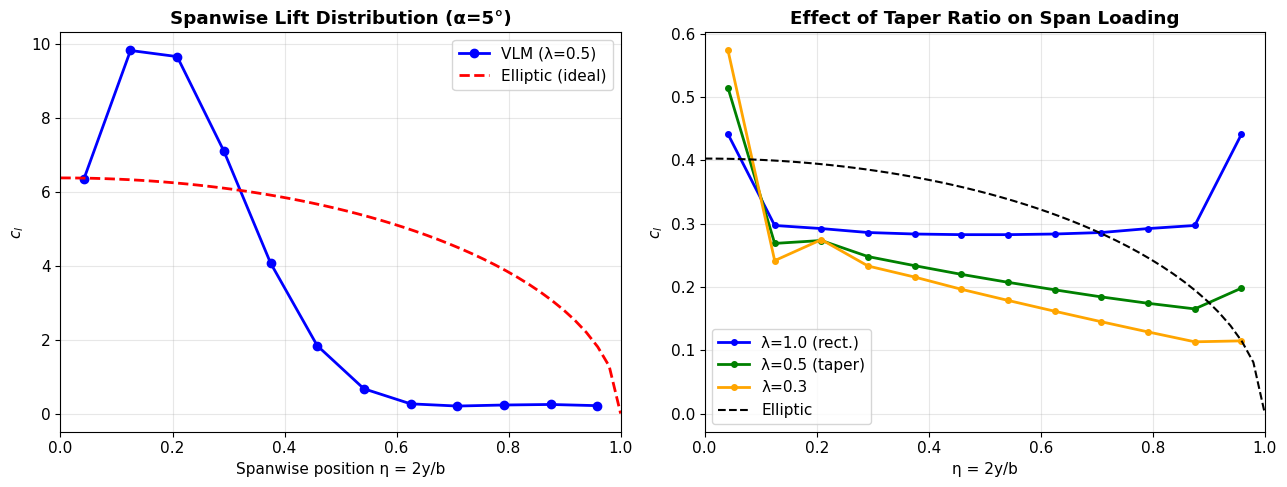

In [4]:
# Solve at a single alpha for detailed span loading
result_5deg = vlm.solve(alpha_deg=5.0)
y_st = result_5deg['y_stations']
cl_dist = result_5deg['CL_distribution']

# Elliptic distribution (reference)
y_norm = y_st / (baseline_wing.span / 2)
cl_elliptic = result_5deg['CL'] * np.sqrt(1 - y_norm**2) / (np.pi / 4)

# Taper ratio effect
wings_taper = {
    'λ=1.0 (rect.)': WingGeometry(span=12, root_chord=1.875, tip_chord=1.875, n_spanwise=12),
    'λ=0.5 (taper)': WingGeometry(span=12, root_chord=2.5, tip_chord=1.25, n_spanwise=12),
    'λ=0.3': WingGeometry(span=12, root_chord=2.885, tip_chord=0.865, n_spanwise=12),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Baseline spanwise distribution
ax = axes[0]
ax.plot(y_st / (baseline_wing.span / 2), cl_dist, 'bo-', linewidth=2,
        markersize=6, label='VLM (λ=0.5)')
ax.plot(np.linspace(0, 1, 50),
        result_5deg['CL'] * np.sqrt(1 - np.linspace(0,1,50)**2) / (np.pi/4),
        'r--', linewidth=2, label='Elliptic (ideal)')
ax.set_xlabel('Spanwise position η = 2y/b')
ax.set_ylabel('$c_l$')
ax.set_title('Spanwise Lift Distribution (α=5°)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)

# Effect of taper ratio
ax = axes[1]
colors_tp = ['blue', 'green', 'orange']
for (label, w), col in zip(wings_taper.items(), colors_tp):
    v = VortexLatticeMethod(w)
    r = v.solve(5.0)
    y_n = r['y_stations'] / (w.span / 2)
    ax.plot(y_n, r['CL_distribution'], color=col, linewidth=2, marker='o',
            markersize=4, label=label)
y_ell = np.linspace(0, 1, 50)
r_base = VortexLatticeMethod(wings_taper['λ=0.5 (taper)']).solve(5.0)
ax.plot(y_ell, r_base['CL'] * np.sqrt(1 - y_ell**2) / (np.pi/4),
        'k--', linewidth=1.5, label='Elliptic')
ax.set_xlabel('η = 2y/b')
ax.set_ylabel('$c_l$')
ax.set_title('Effect of Taper Ratio on Span Loading', fontweight='bold')
ax.legend()
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('span_loading.png', bbox_inches='tight', dpi=100)
plt.show()

## 4. Effect of Aspect Ratio

Higher aspect ratio wings are more aerodynamically efficient (lower induced drag)
but are structurally heavier.

$$C_{D_i} = \frac{C_L^2}{\pi A R \, e}$$

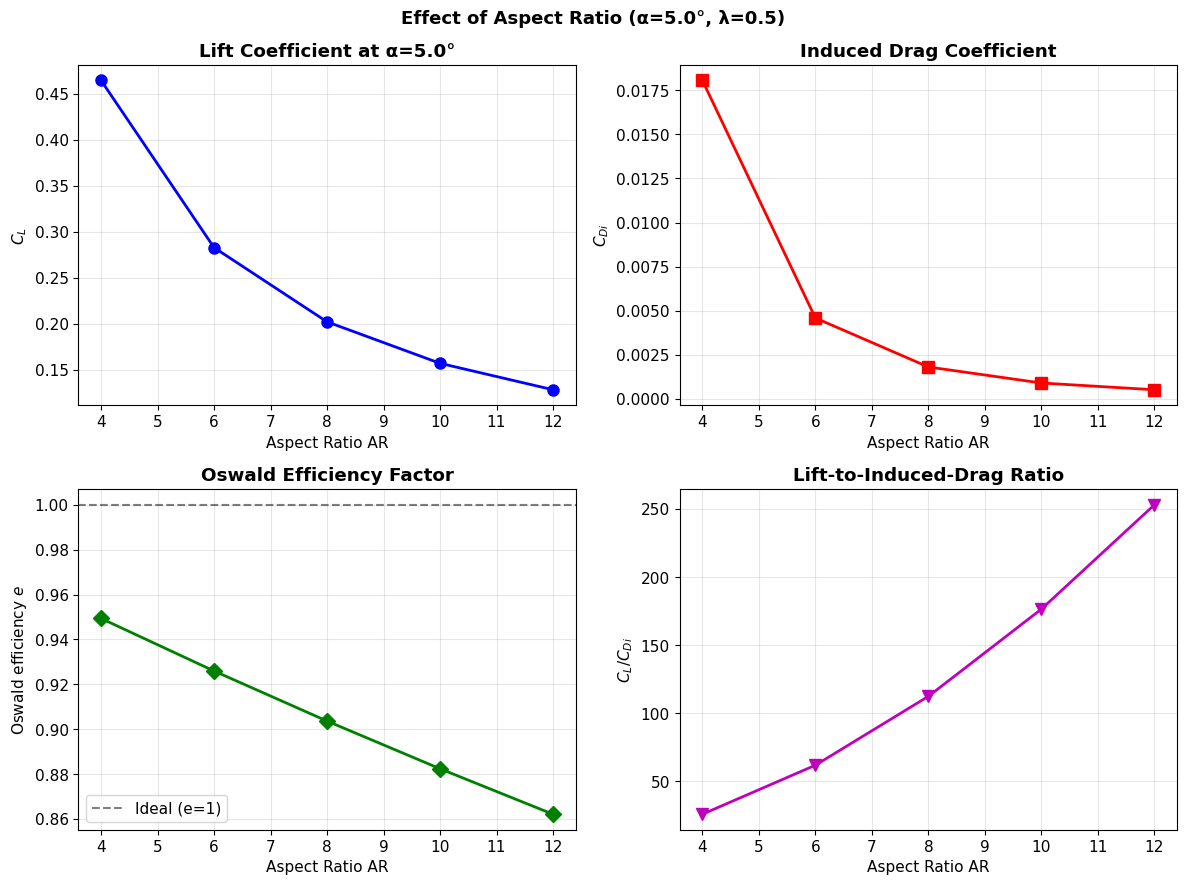

In [5]:
aspect_ratios = [4, 6, 8, 10, 12]
alpha_test = 5.0
results_AR = {}

for AR_val in aspect_ratios:
    # Maintain same reference area by adjusting span and chord
    S = 18.75  # fixed reference area
    b = np.sqrt(AR_val * S)
    c_root = 2 * S / (b * 1.5)  # taper ratio = 0.5
    c_tip = 0.5 * c_root
    w = WingGeometry(span=b, root_chord=c_root, tip_chord=c_tip, n_spanwise=10)
    v = VortexLatticeMethod(w)
    r = v.solve(alpha_test)
    results_AR[AR_val] = r

CL_vals = [results_AR[AR]['CL'] for AR in aspect_ratios]
CDi_vals = [results_AR[AR]['CDi'] for AR in aspect_ratios]
e_vals = [results_AR[AR]['e'] for AR in aspect_ratios]
LD_vals = [c / d for c, d in zip(CL_vals, CDi_vals)]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.plot(aspect_ratios, CL_vals, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Aspect Ratio AR')
ax.set_ylabel('$C_L$')
ax.set_title(f'Lift Coefficient at α={alpha_test}°', fontweight='bold')

ax = axes[0, 1]
ax.plot(aspect_ratios, CDi_vals, 'rs-', linewidth=2, markersize=8)
ax.set_xlabel('Aspect Ratio AR')
ax.set_ylabel('$C_{Di}$')
ax.set_title('Induced Drag Coefficient', fontweight='bold')

ax = axes[1, 0]
ax.plot(aspect_ratios, e_vals, 'gD-', linewidth=2, markersize=8)
ax.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Ideal (e=1)')
ax.set_xlabel('Aspect Ratio AR')
ax.set_ylabel('Oswald efficiency $e$')
ax.set_title('Oswald Efficiency Factor', fontweight='bold')
ax.legend()

ax = axes[1, 1]
ax.plot(aspect_ratios, LD_vals, 'mv-', linewidth=2, markersize=8)
ax.set_xlabel('Aspect Ratio AR')
ax.set_ylabel('$C_L / C_{Di}$')
ax.set_title('Lift-to-Induced-Drag Ratio', fontweight='bold')

plt.suptitle(f'Effect of Aspect Ratio (α={alpha_test}°, λ=0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aspect_ratio_effects.png', bbox_inches='tight', dpi=100)
plt.show()

## 5. Summary

In this notebook we have:
1. Defined trapezoidal wing geometry using `WingGeometry`
2. Applied the Vortex Lattice Method to compute lift and induced drag
3. Studied spanwise load distribution and compared to elliptic ideal
4. Quantified the effect of aspect ratio on aerodynamic efficiency

### Key takeaways
- Higher AR → higher $C_L$ slope, lower $C_{Di}$
- Taper ratio ~0.4–0.5 approximates elliptic loading well
- Induced drag dominates at low speeds (high $C_L$)

### Next steps
Proceed to `../03_wing_fuselage/wing_fuselage_openvsp.ipynb` for 3D modeling with OpenVSP.